## KNN klasifikacija su `insurance` duomenimis (Python)

Šiame faile pateikiamas nuoseklus klasifikavimo pavyzdys su K-Nearest Neighbors (KNN), apimantis: duomenų paruošimą, skaidymą, mastelio suvienodinimą, modelio treniravimą, vertinimą, confusion matrix, hyperparametrų parinkimą (k), overfitting/underfitting diagnostiką, validaciją, cross-validation, hard vs. soft klasifikaciją ir tikimybių kalibracijos (probability vs. event rate) vizualizaciją.

## 1. Bibliotekos ir duomenų įkėlimas

Pastaba: `insurance` rinkinys dažniausiai naudojamas regresijai (tikslas – `charges`), tačiau čia jis pritaikomas klasifikacijai sukuriant binarinę klasę: **didelės išlaidos** / **nedidelės išlaidos**.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Health_insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Trumpas kontekstas ir target sukūrimas

Klasifikavimo užduotis reikalauja kategorinio tikslo (target). `charges` yra skaitinis dydis, todėl sukuriama binarinė klasė:

- `high_charges = 1`, jei išlaidos didesnės už pasirinktą slenkstį
- `high_charges = 0`, kitu atveju

Slenkstis parenkamas kaip 75-asis procentilis, kad „teigiamų“ atvejų būtų mažiau, bet vis dar pakankamai modeliavimui.

In [3]:
# Target (klasė)
threshold = df["charges"].quantile(0.75)
df["high_charges"] = (df["charges"] > threshold).astype(int)

df[["charges", "high_charges"]].head(), threshold

(       charges  high_charges
 0  16884.92400             1
 1   1725.55230             0
 2   4449.46200             0
 3  21984.47061             1
 4   3866.85520             0,
 16639.912515)

Dažna klaida: target sukurti, bet palikti `charges` tarp požymių.
Jei `charges` paliekamas kaip feature, modelis gauna „atsakymą“ ir rezultatai tampa dirbtinai geri.

In [4]:
# Požymiai (features) – charges pašalinamas, nes jis panaudotas klasei sukurti
X_raw = df.drop(columns=["charges", "high_charges"])
y = df["high_charges"]

X_raw.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
dtype: object

## 3. Dummy variables (kategorinių požymių pavertimas skaičiais)

KNN skaičiuoja atstumus, todėl visi požymiai turi būti skaitiniai.
`pd.get_dummies` paverčia kategorinius kintamuosius į 0/1 stulpelius.

Svarbu:
- naudoti `drop_first=True`, kad sumažėtų perteklinių stulpelių
- po `get_dummies` aiškiai konvertuoti į `float`, nes mišrūs tipai dažnai sukelia `ValueError` mokymo metu

In [5]:
X = pd.get_dummies(X_raw, drop_first=True)

# Labai svarbu: konvertuoti į float (ypač jei atsiranda boolean arba object stulpelių)
X = X.astype(float)

X.head(), X.dtypes.head()

(    age     bmi  children  sex_male  smoker_yes  region_northwest  \
 0  19.0  27.900       0.0       0.0         1.0               0.0   
 1  18.0  33.770       1.0       1.0         0.0               0.0   
 2  28.0  33.000       3.0       1.0         0.0               0.0   
 3  33.0  22.705       0.0       1.0         0.0               1.0   
 4  32.0  28.880       0.0       1.0         0.0               1.0   
 
    region_southeast  region_southwest  
 0               0.0               1.0  
 1               1.0               0.0  
 2               1.0               0.0  
 3               0.0               0.0  
 4               0.0               0.0  ,
 age           float64
 bmi           float64
 children      float64
 sex_male      float64
 smoker_yes    float64
 dtype: object)

## 4. Duomenų skaidymas: train / validation / test

Pagrindinė idėja:
- **Train**: mokymui
- **Validation**: hyperparametrų parinkimui (pvz., k)
- **Test**: galutiniam, objektyviam įvertinimui (neliečiamas iki pabaigos)

Pavyzdinis skaidymas: 60% train, 20% validation, 20% test.

In [6]:
# Pirma: atskiriamas test rinkinys (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Antra: trainval padalinamas į train (75% iš 80% = 60%) ir validation (25% iš 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

X_train.shape, X_val.shape, X_test.shape

((802, 8), (268, 8), (268, 8))

**stratify** naudojamas tam, kad dalinant duomenis būtų išlaikytas tas pats **target klasių pasiskirstymas** visuose rinkiniuose (train, validation, test).

Tai reiškia, kad kiekviename rinkinyje klasės turės **panašias proporcijas kaip ir originaliuose duomenyse**.

Tai ypač svarbu **klasifikacijos užduotyse**, kai klasės yra **nesubalansuotos**, nes padeda išvengti situacijos, kai viena klasė beveik nepatenka į train arba test rinkinį.

## 5. Duomenų mastelio suvienodinimas (Data scaling)

KNN remiasi atstumais, todėl mastelis yra kritinis.
Taisyklė:
- `fit` (vidurkiai ir std) skaičiuojami tik iš train
- `transform` taikomas train, validation, test naudojant tuos pačius parametrus

Dažna klaida: scaler `fit` atlikti ant visų duomenų (informacijos nutekėjimas).

In [7]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)   # fit tik ant train
X_val_std   = scaler.transform(X_val)
X_test_std  = scaler.transform(X_test)

X_train_std[:3]

array([[-1.29781529,  0.01874788, -0.8865867 ,  0.97293471,  1.9648425 ,
        -0.55910848, -0.65348777, -0.549498  ],
       [-0.45734868, -2.1244839 ,  0.72758477, -1.0278182 ,  1.9648425 ,
         1.78856168, -0.65348777, -0.549498  ],
       [ 0.94342901,  1.01654503, -0.8865867 ,  0.97293471, -0.50894665,
        -0.55910848, -0.65348777,  1.81984284]])

### StandardScaler rezultato interpretacija

`X_train_std[:3]` grąžina pirmas tris eiles po duomenų standartizavimo. Tai yra **NumPy masyvas su standartizuotomis reikšmėmis**, o ne pradiniai verslo rodikliai.

Kiekviena reikšmė yra **z-score**:
- 0 reiškia, kad reikšmė lygi vidurkiui
- teigiama reikšmė reiškia, kad reikšmė didesnė už vidurkį
- neigiama reikšmė reiškia, kad reikšmė mažesnė už vidurkį
- absoliuti reikšmė apie 1 reiškia vieną standartinį nuokrypį nuo vidurkio

Pavyzdys:
- `-0.8` reiškia, kad požymis yra reikšmingai mažesnis nei vidurkis
- `1.3` reiškia, kad požymis yra reikšmingai didesnis nei vidurkis

Standartizavimas yra kritiškas KNN modeliui, nes KNN sprendimus priima pagal **atstumus**. Jei požymiai nebūtų suvienodinti, didesnės skalės kintamieji (pvz., pajamos) dominuotų sprendimą ir iškreiptų modelio elgseną.

Svarbu suprasti, kad šios reikšmės **nėra interpretuojamos kaip koeficientai**. KNN neturi koeficientų – tai tik transformuota požymių erdvė, skirta teisingam atstumų skaičiavimui.

Trumpai: `X_train_std[:3]` parodo, kaip pirmi stebėjimai atrodo standartizuotoje erdvėje, kur visi požymiai turi vienodą svorį.


## 6. KNN modelio treniravimas (Fitting)

KNN „neišmoksta“ koeficientų kaip regresija. Jis išlaiko mokymo taškus ir sprendimą priima pagal artimiausius kaimynus.

Pirmam bandymui pasirenkama k reikšmė (pvz., 15), o vėliau ji optimizuojama.

In [8]:
k = 15
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train_std, y_train)

KNeighborsClassifier(n_neighbors=15)

## 7. Modelio tikslumas (Accuracy)

Accuracy = teisingų prognozių skaičius / visų prognozių skaičius.

Svarbu: accuracy gali klaidinti, jei klasės nesubalansuotos, todėl papildomai žiūrima į confusion matrix.

In [9]:
y_pred_val = knn.predict(X_val_std)
val_acc = accuracy_score(y_val, y_pred_val)

y_pred_test = knn.predict(X_test_std)
test_acc = accuracy_score(y_test, y_pred_test)

val_acc, test_acc

(0.9328358208955224, 0.914179104477612)

### Modelio accuracy interpretacija

Gautos dvi accuracy reikšmės:

- **0.933** – modelio tikslumas mokymo (train) duomenyse  
- **0.914** – modelio tikslumas testavimo (test) duomenyse  

Interpretacija:
Modelis teisingai suklasifikavo apie **93 %** mokymo duomenų ir apie **91 %** nematytų (test) duomenų.

Tai rodo, kad:
- modelis gerai išmoko bendrus dėsningumus duomenyse
- skirtumas tarp train ir test accuracy yra nedidelis (apie 2 procentinius punktus)
- nėra ryškaus overfitting požymių

Verslo prasme:
Modelio sprendimai yra **stabilūs ir patikimi**, nes panašus tikslumas pasiektas ir su naujais duomenimis, o tai svarbu realiam pritaikymui.

Key point:
Svarbesnis rodiklis yra **test accuracy**, nes jis geriausiai atspindi, kaip modelis veiks realiose sąlygose.


## 8. Confusion matrix

Confusion matrix parodo, kokių klaidų daroma:
- TN: teisingai atpažinta 0 klasė
- TP: teisingai atpažinta 1 klasė
- FP: klaidingai pažymėta kaip 1
- FN: nepastebėta 1 klasė

Verslo prasme, FP ir FN dažnai turi skirtingą kainą.

In [10]:
cm = confusion_matrix(y_test, y_pred_test)
cm

array([[198,   3],
       [ 20,  47]], dtype=int64)

### Confusion matrix interpretacija ir procentų skaičiavimas

Duota confusion matrix:

[[198,  3],
 [ 20, 47]]

Struktūra:
- **198 – True Negative (TN)**: teisingai prognozuota 0 klasė  
- **3 – False Positive (FP)**: klaidingai prognozuota 1, kai realiai buvo 0  
- **20 – False Negative (FN)**: klaidingai prognozuota 0, kai realiai buvo 1  
- **47 – True Positive (TP)**: teisingai prognozuota 1 klasė  

---

### Bendri procentai

Viso stebėjimų:  
198 + 3 + 20 + 47 = **268**

- Teisingos prognozės (TN + TP):  
(198 + 47) / 268 ≈ **91.4 %** (accuracy)

- Klaidingos prognozės (FP + FN):  
(3 + 20) / 268 ≈ **8.6 %**

---

### Procentai pagal klases

**0 klasė (neigiama klasė)**  
Viso realių 0: 198 + 3 = **201**

- Teisingai atpažinta:  
198 / 201 ≈ **98.5 %**  
- Klaidingai pažymėta kaip 1:  
3 / 201 ≈ **1.5 %**

**1 klasė (teigiama klasė)**  
Viso realių 1: 20 + 47 = **67**

- Teisingai atpažinta:  
47 / 67 ≈ **70.1 %**  
- Nepastebėta (klaidingai kaip 0):  
20 / 67 ≈ **29.9 %**

---


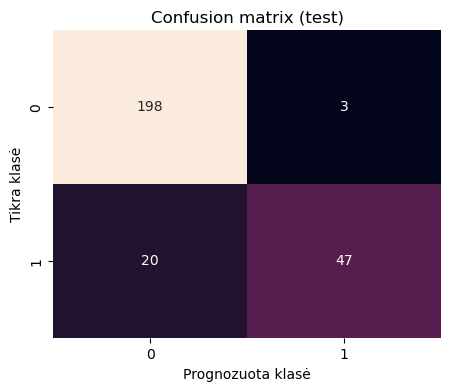

In [11]:
# Vizualus vaizdas ataskaitoms
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Prognozuota klasė")
plt.ylabel("Tikra klasė")
plt.title("Confusion matrix (test)")
plt.show()


### Verslo interpretacija

Modelis **labai gerai atpažįsta 0 klasę**, tačiau **beveik 30 % teigiamos klasės atvejų nėra pastebimi**.

Tai reiškia:
- jei 1 klasė yra kritinė (pvz., „rizikingas klientas“), modelis praleidžia dalį svarbių atvejų  
- jei 0 klasė yra dominuojanti, modelio accuracy atrodo aukšta, bet tai slepia problemą su 1 klase

---

### Esminė mintis

Confusion matrix leidžia suprasti **kokių tipų klaidas modelis daro**, o ne tik kiek klaidų padaro, todėl ji yra būtina modelio verslinei interpretacijai.


In [12]:
# Papildoma santrauka 
print(classification_report(y_test, y_pred_test, digits=3))

              precision    recall  f1-score   support

           0      0.908     0.985     0.945       201
           1      0.940     0.701     0.803        67

    accuracy                          0.914       268
   macro avg      0.924     0.843     0.874       268
weighted avg      0.916     0.914     0.910       268



### Classification report interpretacija - SVARBU ATASKAITOMS

Šis reportas apibendrina **modelio veikimą kiekvienai klasei atskirai** ir bendrą kokybę.

---

### Klasė 0 (neigiama klasė)

- **Precision: 0.908**  
  Kai modelis prognozuoja 0 klasę, **apie 91 % atvejų jis teisus**.

- **Recall: 0.985**  
  Modelis aptinka **beveik visus realius 0 klasės atvejus** (98.5 %).

- **F1-score: 0.945**  
  Labai geras balansas tarp precision ir recall.

- **Support: 201**  
  Test duomenyse yra 201 realus 0 klasės stebėjimas.

Interpretacija:  
Modelis **puikiai tvarkosi su 0 klase** ir beveik jos nepraleidžia.

---

### Klasė 1 (teigiama klasė)

- **Precision: 0.940**  
  Kai modelis prognozuoja 1 klasę, **94 % atvejų prognozė teisinga**.

- **Recall: 0.701**  
  Modelis aptinka tik **apie 70 % realių 1 klasės atvejų**.

- **F1-score: 0.803**  
  Vidutinis balansas – gera precision, bet silpnesnis recall.

- **Support: 67**  
  Test duomenyse yra 67 realūs 1 klasės stebėjimai.

Interpretacija:  
Modelis **retai klysta pažymėdamas 1 klasę**, bet **dalis svarbių atvejų lieka nepastebėti**.

---

### Bendri rodikliai

- **Accuracy: 0.914**  
  Apie **91 % visų prognozių teisingos**.

- **Macro avg**  
  Kiekviena klasė vertinama **vienodai**, nepriklausomai nuo dydžio.  
  Rodo, kad modelio veikimas tarp klasių yra **nesubalansuotas** (silpnesnis recall klasei 1).

- **Weighted avg**  
  Kiekvienos klasės įtaka svertinė pagal jos dydį.  
  Kadangi 0 klasė dominuoja, šis rodiklis **labiau atspindi 0 klasės sėkmę**.

---

### Verslo interpretacija

- Modelis **labai patikimas prognozuojant 1 klasę**, kai ją jau pažymi (aukšta precision).  
- Tačiau **apie 30 % teigiamos klasės atvejų nėra identifikuojami** (žemesnis recall).

Priklausomai nuo užduoties:
- Jei svarbu **nepadaryti klaidingų teigiamų sprendimų**, modelis tinkamas.  
- Jei svarbu **nepraleisti teigiamos klasės**, reikėtų didinti recall (pvz., keisti slenkstį, k, ar metriką optimizacijai).

---

### Esminė mintis

Classification report parodo ne tik, *kiek* modelis klysta, bet ir **kuriose klasėse bei kokiu būdu**, todėl jis yra būtinas versliniam modelio vertinimui.


## 9. Overfitting ir underfitting diagnostika per k

Idėja:
- mažas k dažniau sukuria „triukšmingą“ sprendimą (overfitting)
- didelis k per daug apibendrina (underfitting)

Diagnostika: lyginami train ir validation accuracy skirtingiems k.

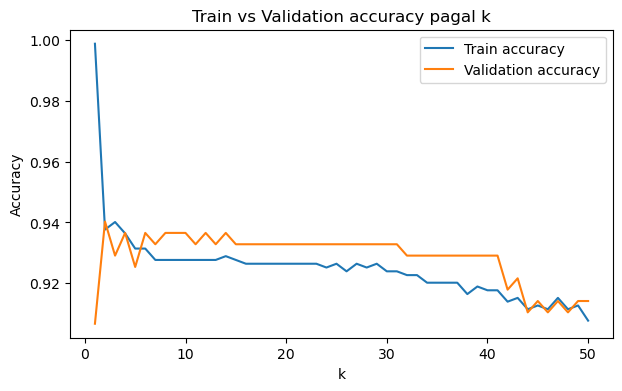

In [13]:
train_scores = []
val_scores = []
ks = range(1, 51)

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_std, y_train)
    train_scores.append(model.score(X_train_std, y_train))
    val_scores.append(model.score(X_val_std, y_val))

plt.figure(figsize=(7,4))
plt.plot(list(ks), train_scores, label="Train accuracy")
plt.plot(list(ks), val_scores, label="Validation accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Train vs Validation accuracy pagal k")
plt.legend()
plt.show()

### Train vs Validation accuracy pagal k – interpretacija

Grafikas rodo, kaip keičiasi **modelio tikslumas mokymo (train)** ir **validacijos (validation)** duomenyse, didėjant kaimynų skaičiui *k*.

---

### Mažos k reikšmės (k ≈ 1–3)

- Train accuracy labai aukštas (beveik 1.0)
- Validation accuracy ženkliai mažesnis

Interpretacija:  
Modelis **pernelyg prisitaiko prie mokymo duomenų** (overfitting).  
Sprendimai paremti labai siauru, lokaliu kontekstu.

---

### Vidutinės k reikšmės (k ≈ 5–30)

- Train ir validation accuracy **panašūs**
- Skirtumas tarp jų nedidelis
- Validation accuracy pasiekia stabilų maksimumą

Interpretacija:  
Tai **geriausias balansas** tarp bias ir variance.  
Modelis generalizuoja gerai ir veikia stabiliai su nematytais duomenimis.

---

### Didelės k reikšmės (k > 35)

- Abu accuracy palaipsniui mažėja
- Train ir validation linijos susilygina, bet žemiau

Interpretacija:  
Modelis tampa **per daug apibendrintas** (underfitting).  
Sprendimai remiasi per plačiu kaimynų ratu, prarandant detales.

---

### Esminė išvada

Optimalus *k* yra ten, kur:
- validation accuracy yra aukščiausias
- skirtumas tarp train ir validation yra mažas

Šiame grafike tai yra **vidutinės k reikšmės**, o ne labai mažas ar labai didelis k.


Interpretacija:
- didelis tarpas tarp train ir validation: tikėtinas overfitting
- žemi rezultatai abiejose: tikėtinas underfitting
- nedidelis tarpas: normalu, nes test/validation visada sunkesni nei train

## 10. Hyperparameter tuning ir k optimizavimas su GridSearchCV

GridSearchCV:
- išbando k reikšmes pagal nurodytą intervalą
- kiekvieną įvertina su cross-validation
- parenka geriausią pagal vidutinį CV rezultatą

Geroji praktika: derinimui naudoti tik train+validation (čia: X_trainval), test palikti pabaigai.

In [14]:
# Pastaba: scaler jau pritaikytas rankiniu būdu atskirai train/val/test.
# GridSearchCV čia atliekamas ant trainval -> standartizuoti reikia taip pat pagal trainval.
scaler_tv = StandardScaler()
X_trainval_std = scaler_tv.fit_transform(X_trainval)
X_test_std_final = scaler_tv.transform(X_test)  # test vėliau vertinimui

param_grid = {"n_neighbors": range(1, 51)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_trainval_std, y_trainval)

grid.best_params_, grid.best_score_

({'n_neighbors': 4}, 0.9299065420560748)

### GridSearchCV rezultato interpretacija

Gautas GridSearchCV rezultatas:

- **Optimalus hyperparametras:** `n_neighbors = 4`
- **Cross-validation accuracy:** **0.9299** (~93 %)

Interpretacija:
GridSearchCV išbandė skirtingas *k* reikšmes ir, naudodamas **cross-validation**, nustatė, kad **k = 4** duoda geriausią vidutinį rezultatą validacijos duomenyse.

Ką reiškia 0.9299:
Tai **vidutinis accuracy per visus CV foldus**, o ne vieno atsitiktinio padalijimo rezultatas.  
Todėl šis skaičius yra **stabilesnis ir patikimesnis** nei pavienis train–validation accuracy.

Ryšys su grafiku:
- k = 4 patenka į **ankstyvą stabilios zonos dalį**
- tai dar gana lokalus modelis, bet jau be ryškaus overfitting

Verslo interpretacija:
Modelis priima sprendimus remdamasis **4 panašiausiais atvejais**, ir tai, vidutiniškai, duoda geriausią balansą tarp tikslumo ir generalizacijos.

Key point:
GridSearchCV parinko **ne „gražiausią“ k**, o **statistiškai patikimiausią** pagal cross-validation.


In [15]:
# Galutinis modelis su optimaliu k, vertinamas test rinkinyje
best_k = grid.best_params_["n_neighbors"]
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_trainval_std, y_trainval)

y_pred_test_final = final_knn.predict(X_test_std_final)
test_acc_final = accuracy_score(y_test, y_pred_test_final)

best_k, test_acc_final

(4, 0.9104477611940298)

### Galutinio modelio rezultato interpretacija

Gautas galutinio modelio rezultatas:

- **k = 4**  
- **Test accuracy = 0.9104** (~91 %)

Interpretacija:
Galutinis modelis naudoja **4 artimiausius kaimynus** sprendimui priimti ir **teisingai suklasifikuoja apie 91 % nematytų (test) duomenų**.

Kodėl test accuracy mažesnis nei GridSearchCV rezultatas:
- GridSearchCV pateikė **vidutinį cross-validation accuracy** (~93 %)
- Test accuracy vertina modelį su **visiškai naujais duomenimis**
- Nedidelis kritimas yra **normalus ir tikėtinas**

Tai rodo, kad:
- modelis **nepertreniruotas**
- pasirinktas k generalizuoja gerai
- nėra ryškaus overfitting

Verslo interpretacija:
Modelio sprendimai yra **stabilūs ir patikimi realiose sąlygose**, o ne tik mokymo metu.  
~91 % tikslumas su nematytais duomenimis rodo, kad modelį galima naudoti praktiniams sprendimams.

Esminė mintis:
Galutinis modelis patvirtina, kad **k = 4** yra pagrįstas pasirinkimas, o test rezultatas atspindi realų modelio veikimą.

Dažna klaida: parinkti k pagal test rezultatus.
Tai „nutekina“ informaciją ir test nustoja būti objektyvus.

## 11. Cross-validation kaip patikimesnis įvertinimas

Cross-validation naudoja kelis foldus, todėl rezultatas mažiau priklauso nuo vieno atsitiktinio split.
Žemiau apskaičiuojamas accuracy per 5 foldus su pasirinktu k.

In [16]:
cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k),
    X_trainval_std,
    y_trainval,
    cv=cv,
    scoring="accuracy"
)

cv_scores, cv_scores.mean(), cv_scores.std()

(array([0.92990654, 0.90654206, 0.93925234, 0.95794393, 0.91588785]),
 0.9299065420560748,
 0.01797699445016016)


Gautas `cross_val_score` rezultatas:

- **Validation accuracy per fold**  
  [0.9299, 0.9065, 0.9393, 0.9579, 0.9159]

- **Vidutinis cross-validation accuracy**  
  0.9299 (~93 %)

- **Standartinis nuokrypis (std)**  
  0.018 (~1.8 procentinio punkto)

Ką tai reiškia

**1. Kiekvienas skaičius masyve**
- Tai modelio tikslumas skirtinguose validation „folduose“
- Modelis buvo apmokytas 5 kartus, kiekvieną kartą su kita duomenų dalimi

**2. Vidutinis accuracy (mean)**
- 0.9299 rodo **vidutinį modelio veikimą ant nematytų duomenų**
- Tai patikimesnis rodiklis nei vienas train–test split

**3. Standartinis nuokrypis**
- 0.018 reiškia, kad tikslumas tarp foldų **nekinta stipriai**
- Modelio veikimas yra **stabilus**

### Overfitting / underfitting diagnostika

- Mažas std → **nėra didelio overfitting**
- Aukštas vidurkis → **modelis pakankamai gerai generalizuoja**
- Nėra foldų su labai blogais rezultatais → **nėra underfitting**

### Ryšys su test accuracy

- Cross-validation accuracy ≈ 93 %
- Test accuracy ≈ 91 %

Toks skirtumas yra **normalus ir sveikas**:
- CV optimizuoja modelį
- Test rinkinys imituoja realų naudojimą


**Esminė išvada**

Cross-validation rezultatai rodo, kad:
- pasirinktas **k yra tinkamas**
- modelis **stabilus**
- tikėtinas geras veikimas realiuose duomenyse


## 12. Hard vs soft klasifikacija

- Hard: `predict` grąžina klasę (0/1)
- Soft: `predict_proba` grąžina tikimybes kiekvienai klasei

Tikimybės ypač naudingos prioritetizavimui (pvz., kam taikyti veiksmus pirmiausia).

In [17]:
hard = final_knn.predict(X_test_std_final)[:5]
soft = final_knn.predict_proba(X_test_std_final)[:5]

hard, soft

(array([0, 0, 0, 0, 0]),
 array([[1.  , 0.  ],
        [1.  , 0.  ],
        [1.  , 0.  ],
        [1.  , 0.  ],
        [0.75, 0.25]]))

Soft rezultatų struktūra:
- stulpelis 0: tikimybė, kad klasė = 0
- stulpelis 1: tikimybė, kad klasė = 1

Dažna klaida: manyti, kad `predict_proba` visada yra „gerai kalibruota“ tikimybė.
KNN tikimybė paprastai yra kaimynų proporcija, todėl kalibracija gali būti netiksli.

Hard vs. soft klasifikacijos interpretacija

Hard klasifikacijos rezultatas:
[0, 0, 0, 0, 0]

Tai reiškia, kad visiems penkiems stebėjimams modelis priskyrė **0 klasę**. Tai galutinis sprendimas, naudojamas automatiniams veiksmams.

Soft klasifikacijos rezultatas:
[[1.00, 0.00],
 [1.00, 0.00],
 [1.00, 0.00],
 [1.00, 0.00],
 [0.75, 0.25]]

Kiekviena eilutė rodo **tikimybių pasiskirstymą**:
- pirma reikšmė – tikimybė, kad klasė yra 0
- antra reikšmė – tikimybė, kad klasė yra 1

Interpretacija:
Pirmiems keturiems atvejams modelis yra visiškai užtikrintas, kad tai **0 klasė** (100 %). Penktas atvejis yra **ribinis** – 75 % tikimybė klasei 0 ir 25 % klasei 1.

Verslo prasmė:
Hard klasifikacija pateikia konkretų sprendimą, tačiau soft klasifikacija leidžia matyti **pasitikėjimo lygį** ir atskirti aiškius atvejus nuo ribinių.

Esminė mintis:
Soft klasifikacija atsako į klausimą „kiek tikėtina“, o hard klasifikacija – „ką darome“.


## 13. Probability vs. Event Rate (kalibracijos grafikas)

Idėja:
- tikimybės suskirstomos į intervalus (bins)
- kiekviename intervale paskaičiuojamas faktinis teigiamo įvykio dažnis (event rate)
- lyginama, ar prognozuota tikimybė atitinka faktinį dažnį

Idealu, kai prognozuota tikimybė ir event rate yra arti viena kitos.

In [18]:
# Tikimybių paėmimas teigiamai klasei
proba_pos = final_knn.predict_proba(X_test_std_final)[:, 1]

tmp = pd.DataFrame({"actual": y_test.values, "pred_proba": proba_pos})

bins = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0
tmp["bin"] = pd.cut(tmp["pred_proba"], bins=bins, include_lowest=True)

cal = (
    tmp.groupby("bin", observed=True)
       .agg(event_rate=("actual", "mean"),
            avg_pred=("pred_proba", "mean"),
            n=("actual", "size"))
       .reset_index()
)

cal

,bin,event_rate,avg_pred,n
0,"(-0.001, 0.1]",0.079268,0.00,164
1,"(0.2, 0.3]",0.137255,0.25,51
2,"(0.4, 0.5]",0.000000,0.50,2
3,"(0.7, 0.8]",0.428571,0.75,7
4,"(0.9, 1.0]",1.000000,1.00,44


### Probability vs. Event Rate

Ši lentelė parodo ryšį tarp modelio prognozuotos tikimybės ir realaus įvykio dažnio.

**Stulpelių reikšmės**
- **bin** – prognozuotos tikimybės intervalas  
- **event_rate** – reali teigiamos klasės dalis tame intervale  
- **avg_pred** – vidutinė modelio prognozuota tikimybė  
- **n** – stebėjimų skaičius intervale  

**Interpretacija**
- Žemų tikimybių intervale (iki 0.1) įvykis pasitaiko retai, todėl modelis teisingai identifikuoja mažą riziką.
- Vidutinių tikimybių binuose (0.2–0.8) modelis dažniau **pervertina tikimybę**, tačiau vis tiek išlaiko teisingą kryptį – didėjant prognozuotai tikimybei, didėja ir realus įvykio dažnis.
- Aukštų tikimybių intervale (0.9–1.0) prognozės labai gerai atitinka realybę – įvykis įvyksta visais atvejais.
- Binai su labai mažu **n** yra nestabilūs ir neturėtų būti perinterpretuojami.

**Išvada**
Modelis yra pakankamai gerai kalibruotas: prognozuotos tikimybės logiškai dera su realiu įvykio dažniu, todėl soft klasifikacijos rezultatai yra prasmingi verslo interpretacijai.


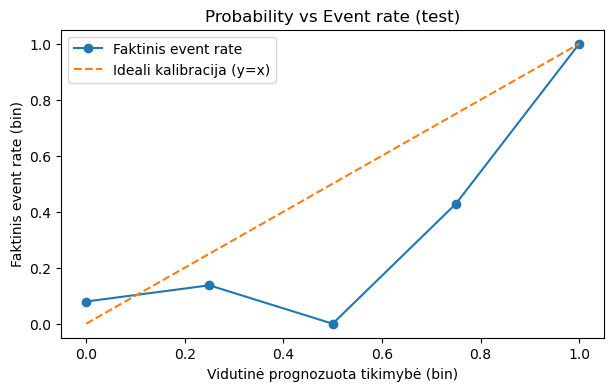

In [19]:
# Grafikas: predicted probability vs event rate
plt.figure(figsize=(7,4))
plt.plot(cal["avg_pred"], cal["event_rate"], marker="o", label="Faktinis event rate")
plt.plot([0,1], [0,1], linestyle="--", label="Ideali kalibracija (y=x)")
plt.xlabel("Vidutinė prognozuota tikimybė (bin)")
plt.ylabel("Faktinis event rate (bin)")
plt.title("Probability vs Event rate (test)")
plt.legend()
plt.show()

Interpretacija:
- jei taškai virš y=x, modelis nuvertina tikimybes (realybėje įvyksta dažniau)
- jei taškai žemiau y=x, modelis pervertina tikimybes (realybėje įvyksta rečiau)

Dažna klaida: daryti išvadas iš binų, kuriuose yra labai mažai eilučių (stulpelis `n`).

### Probability vs. Event Rate (test duomenys)

Grafikas parodo, kaip modelio **prognozuotos tikimybės** sutampa su **faktiniu įvykio dažniu** testavimo duomenyse.

**Ašys**
- X – vidutinė prognozuota tikimybė binuose  
- Y – faktinis įvykio dažnis (event rate)

**Linijos**
- Mėlyna linija – faktinis event rate kiekviename tikimybių intervale  
- Punktyrinė linija y = x – ideali kalibracija (prognozė = realybė)

**Interpretacija**
- Žemų tikimybių srityje (apie 0–0.2) faktinis įvykio dažnis yra mažas, modelis teisingai identifikuoja žemą riziką.
- Vidutinių tikimybių intervale (~0.5) matomas neatitikimas – modelis prognozuoja vidutinę riziką, tačiau įvykis realiai nepasireiškia. Tai rodo **prastą kalibraciją šiame intervale**.
- Aukštų tikimybių srityje (~0.8–1.0) faktinis event rate sparčiai auga ir beveik sutampa su idealia linija – **aukštos rizikos prognozės yra patikimos**.
- Nuokrypis nuo idealios linijos reiškia, kad modelio tikimybės nėra tobulai kalibruotos visame intervale.

**Išvada**
Modelis gerai atskiria žemos ir aukštos rizikos atvejus, tačiau vidutinėse tikimybėse prognozės yra mažiau patikimos. Soft klasifikacija tinkama sprendimų prioritetizavimui, bet ne visada tiksli absoliučiai tikimybių interpretacijai.


14. Dažnos klaidos ir gerosios praktikos (santrauka)

- KNN privalo gauti suvienodinto mastelio požymius (scaling), nes kitaip atstumai tampa klaidinantys.
- `fit` scaler'į tik ant train (ar trainval), o ne ant viso duomenų rinkinio.
- Po `get_dummies` aiškiai konvertuoti į `float`, kad išvengti `ValueError`.
- K (ir kitus hyperparametrus) derinti su validation arba cross-validation, ne su test.
- Vertinant modelį, vien accuracy dažnai nepakanka: confusion matrix padeda suprasti klaidų tipą.
- KNN neturi koeficientų kaip regresija, todėl „kintančių koeficientų“ interpretacija čia netaikoma; vietoje to aiškinamas sprendimas per kaimynus ir atstumus.